lorentz transformation & rejection sampling

In [ ]:
import numpy as np
ARTICLE_SPATIAL_MSD = np.array([
    [0.5733021376706843, 250182038939203700],
    [0.6003441847550387, 262163851955228450],
    [0.6596725389675675, 289146855896921800],
    [0.7392837261108433, 330332810068291900],
    [0.8285026212364475, 367690815603756100],
    [0.8691473526152133, 390245456351716860],
    [0.9033732409093173, 410770183610153860],
    [0.9411253270171814, 425103906545462600],
    [0.9895857083312909, 451976019577617800],
    [1.0245893654990135, 470720078388777400],
    [1.0665828757500415, 497561104101120900],
    [1.1267132911202538, 526758859435288400],
    [1.171760449044476, 557840324139858800],
    [1.2214359018903205, 594601089372626200],
    [1.2769108084654648, 623162526085324900],
    [1.3541187600319222, 667285638932872700],
    [1.4307050690580918, 723349345314142500],
    [1.4873634809428309, 760769360159866000],
    [1.5639507317265462, 807619709128344300],
    [1.6334039604955817, 866393308160470400],
    [1.7019927757021318, 916319368576459000],
    [1.843832366842081, 1015031651481789400],
    [1.9081310167833896, 1057686645791300000],
    [2.029767468454885, 1146396804242570100],
    [2.2226175645177677, 1307996183144134100],
    [2.451085129027217, 1483161837582540500],
    [2.7082623892754083, 1708813557192702500],
    [2.932356927058129, 1907251373207203800],
    [3.1186817521097145, 2084035590250121700],
    [3.2536163205549915, 2181228992706594300],
    [3.3926414653765833, 2350069920092020700],
    [3.56045276687349, 2470450816889040400],
    [3.742341745666627, 2645878395482147000],
    [3.9025010486543477, 2780866492535223000],
    [4.041841135095643, 2941613431484248000],
    [4.263664372804875, 3084590017548192000],
    [4.4389850877344275, 3290919076875113500],
    [4.659751689272642, 3480786374559390000],
    [4.840129943186195, 3610298750318438400],
    [5.109052387057268, 3846656419256969700],
    [5.269378609902595, 3960721264604887600],
    [5.583674841533318, 4261539341039514000],
    [6.211776714557147, 4681279478508967000],
    [6.674444463022679, 5028867996339803000],
    [6.900753483856226, 5241844032179710000],
    [7.35389437557485, 5546343953543199000],
    [7.7176423869194615, 5701635146250873000],
    [8.038093698346483, 5876028071244556000],
    [8.327776425346734, 6084318379997849000],
    [8.903233206054361, 6351253799799482000],
    [9.551599058888739, 6568304436316444000],
    [9.775531293226985, 6633414809895035000],
], dtype=float)

ARTICLE_ENERGY_MSD = np.array([
    [0.517368052936592, 2.6979060805390593e7],
    [0.5438237078749198, 3.0861130976818338e7],
    [0.5716281774591903, 3.595327236424125e7],
    [0.6008575276539287, 4.1288128897320986e7],
    [0.6315776912906184, 4.816361147275011e7],
    [0.6638731332222814, 5.516597656464285e7],
    [0.6978154569444731, 6.42684606133783e7],
    [0.7334964718258326, 7.399786433038157e7],
    [0.7709984785344878, 8.620764328568573e7],
    [0.8104207111178334, 9.951798444004793e7],
    [0.8518582322035683, 1.1503357737641646e8],
    [0.8873250848321875, 1.3247671567461658e8],
    [0.9433348533139936, 1.5418489448936197e8],
    [1.0258513712248105, 2.0179867781781262e8],
    [1.1145024796751264, 2.6350068704674944e8],
    [1.1877746841013657, 3.2462700702508277e8],
    [1.2466163193985274, 3.7762874316778815e8],
    [1.3103438141358568, 4.48056937814454e8],
    [1.377337337845028, 5.233525015140118e8],
    [1.4477437245337745, 6.250269516143988e8],
    [1.5217590085644164, 7.338864420541396e8],
    [1.5995487051658717, 8.753183833884166e8],
    [1.6813241146647204, 1.0291138539947618e9],
    [1.7672722698094248, 1.2242386854141498e9],
    [1.8576168202509429, 1.4506645781539228e9],
    [1.952577914927242, 1.723464830229427e9],
    [2.0523893060373997, 2.0582914306068065e9],
    [2.157310373756831, 2.4357937865865026e9],
    [2.2675872276610534, 2.9090082894171257e9],
    [2.383509519973372, 3.442536956198623e9],
    [2.5053441599113855, 4.132873128496898e9],
    [2.633423556316684, 4.878105795022455e9],
    [2.7680313322371637, 5.863972604194731e9],
    [2.9095341341923127, 6.957610234917751e9],
    [3.058258392097324, 8.341925419916332e9],
    [3.21459610477873, 9.910640470672035e9],
    [3.378907213096748, 1.194474685257441e10],
    [3.5516151578471566, 1.4415158904130249e10],
    [3.733167600789285, 1.7193196202035366e10],
    [3.9239791318440487, 2.080336620793867e10],
    [4.124570299404603, 2.4747782375812443e10],
    [4.335383070186291, 3.0022565027542213e10],
    [4.557009482010345, 3.562180791306691e10],
    [4.780307373504349, 4.2410714736162865e10],
    [5.040460419842247, 5.2426504200209694e10],
    [5.462650674832678, 7.161427515083737e10],
    [5.913470827055889, 9.867901967927754e10],
    [6.387043732865271, 1.3282022587348674e11],
    [6.7592862150787845, 1.6535686785338718e11],
    [7.104738296996037, 2.0244382361919254e11],
    [7.467841936258368, 2.4817274293588498e11],
    [7.849459676437047, 3.0863376733979236e11],
    [8.250615735600396, 3.7933900471499915e11],
    [8.67231667354489, 4.601919381540272e11],
    [9.115525827293292, 5.65617797760355e11],
    [9.516490226801432, 6.747307152053966e11],
], dtype=float)

ARTICLE_MEAN_DW = np.array([
    [0.5205494547820988, 2395.146000163378],
    [0.5463029631562685, 2587.549074430758],
    [0.5733178433350854, 2747.337939605748],
    [0.601672876419838, 2933.137837154263],
    [0.6314290102348303, 3126.569106451835],
    [0.6626527345741359, 3317.027762294672],
    [0.6923871663666791, 3545.3906379303194],
    [0.7282247550169536, 3786.2233503860607],
    [0.8037886090742917, 4278.315816398527],
    [0.8813852718340769, 4846.74750017236],
    [0.924965419151413, 5125.801829940819],
    [0.9707288447122868, 5546.298557022766],
    [1.018749245009389, 5968.260569214557],
    [1.069153783278579, 6462.962295180384],
    [1.122038570838005, 6932.765282502893],
    [1.1775475916575107, 7477.87621368074],
    [1.2358077281333626, 8091.32608507638],
    [1.2969385340480801, 8693.194710588428],
    [1.3611097631803653, 9428.618901094518],
    [1.428428686912249, 10074.207345209594],
    [1.4990968261562359, 10874.895048118075],
    [1.5732785980504185, 11841.47550762397],
    [1.6511078379921067, 12752.424683615496],
    [1.7328135214603873, 13896.83587021309],
    [1.8185367058460056, 14977.705562262297],
    [1.908512235577953, 16219.189024106883],
    [2.0029617449674477, 17716.565705671117],
    [2.102047177411688, 19079.477863078322],
    [2.206067761265165, 20791.683066611233],
    [2.315196057816672, 22355.879704191822],
    [2.429766849087437, 24381.327008617638],
    [2.5499841417431077, 26402.26500430698],
    [2.664417633973295, 28311.56496309705],
    [2.8085824961508394, 31181.040808112168],
    [2.9475066537183188, 33447.64015534973],
    [3.0934088891105738, 36853.814349141256],
    [3.392155757994211, 42853.01785164251],
    [3.711616809522305, 49845.63452202041],
    [4.043385286842983, 57692.655230718825],
    [4.41450974232402, 67263.98868661914],
    [4.8408632060624655, 78477.2253730501],
    [5.296754678365717, 91233.88924954395],
    [5.795547093097313, 105595.06181663263],
    [6.3412956243061505, 121993.26825188448],
    [6.923294815735579, 141588.01463117026],
    [7.591754530150505, 161960.13639634],
    [8.30650595692438, 184661.90715069752],
    [9.068896196998104, 214794.43911836733],
    [9.836060307778428, 243025.38425676408],
], dtype=float)


with article data

=== Simulation settings ===
USE_LORENTZ   = True
USE_REJECTION = True
dx            = 1.667e+07 cm
lambda_sc     = 1.667e+08 cm
dt            = 2.778e-04 s
total time    = 13.889 s
particles     = 5000

Generating scatterer grid...
actual scatterer density = 0.10001
Initializing particles...
Running simulation...
step 5000/50000, active=3934
step 10000/50000, active=3007
step 15000/50000, active=2204
step 20000/50000, active=1600
step 25000/50000, active=1178
step 30000/50000, active=844
step 35000/50000, active=573
step 40000/50000, active=412
step 45000/50000, active=291
Done.
final active = 198
event count percentiles:
[   0.     213.    1156.4   2049.03  2368.005 2495.   ]

Global fits:
a_r  = 1.745
a_W  = 1.805
a_W2 = 3.558

Digitized article fits:
article a_r  = 1.237
article a_W  = 1.601
article a_W2 = 3.476

Fixed-sample Fig.3c:
survive full fit range = 1163 / 5000
valid for bins         = 1163 / 5000
E=6.492e+04 eV, a_r=1.617, N=60
E=1.030e+05 eV, a_r=1.690, N=105
E=1.635e+05 

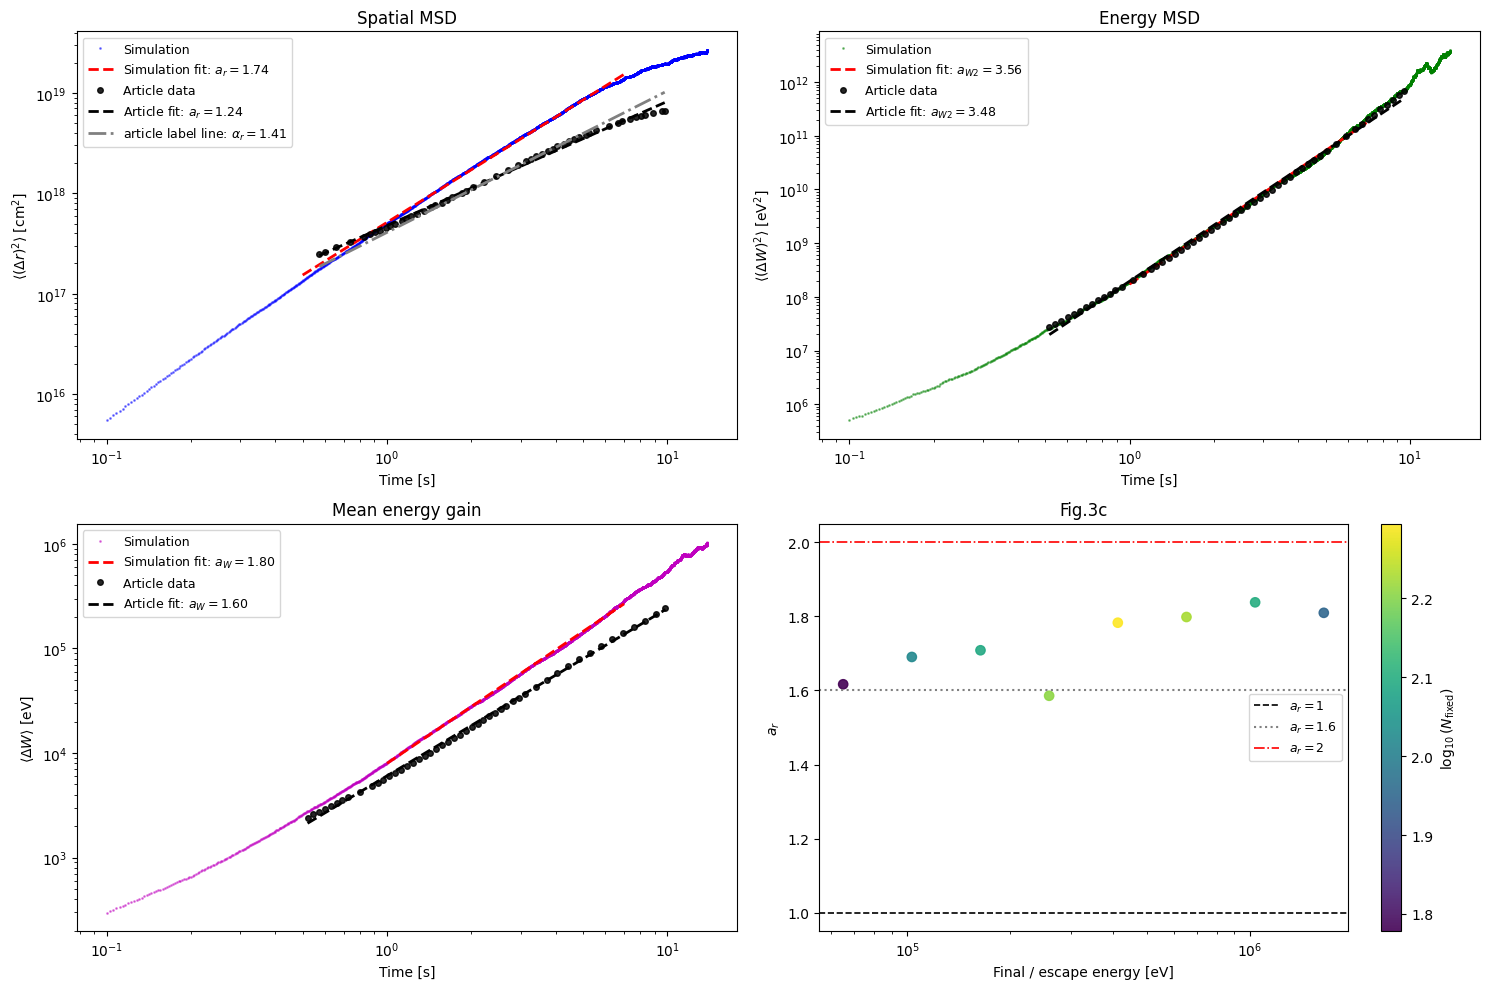

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 0. Switches and parameters
# ============================================================

USE_LORENTZ = True
USE_REJECTION = True

SEED = 42

L_BOX = 1.0e10
N_GRID = 600
SCATTER_DENSITY = 0.10

N_PARTICLES = 5000
N_STEPS = 50000
RECORD_EVERY = 10

V_INIT_MEAN = 6.0e8
V_INIT_SIGMA_FRAC = 0.20

TMIN_R = 0.5
TMIN_E = 1.0
TMAX_FIT = 7.0

N_BINS_3C = 12
MIN_BIN_3C = 60

# ============================================================
# 1. Constants
# ============================================================

C = 3.0e10
M_E = 9.11e-28
M_E_C2 = 8.187e-7
V_A = 7.0e8

ERG_TO_EV = 6.242e11
EV_TO_ERG = 1.0 / ERG_TO_EV




# ============================================================
# 2. Utilities
# ============================================================

def unit_vectors(n, rng):
    u = rng.uniform(-1.0, 1.0, n)
    phi = rng.uniform(0.0, 2.0 * np.pi, n)
    s = np.sqrt(1.0 - u * u)
    return np.column_stack([s * np.cos(phi), s * np.sin(phi), u])


def speed_from_energy_relativistic(W_erg):
    gamma = 1.0 + W_erg / M_E_C2
    beta2 = 1.0 - 1.0 / (gamma * gamma)
    beta2 = np.clip(beta2, 0.0, 1.0 - 1e-14)
    return C * np.sqrt(beta2)


def fit_power(t, y, tmin, tmax):
    mask = (
        (t >= tmin)
        & (t <= tmax)
        & (t > 0)
        & (y > 0)
        & np.isfinite(t)
        & np.isfinite(y)
    )

    if np.sum(mask) < 5:
        return np.nan, lambda x: np.full_like(x, np.nan, dtype=float)

    a, b = np.polyfit(np.log(t[mask]), np.log(y[mask]), 1)
    return a, lambda x: np.exp(b) * x**a


def fit_article_data(article_data):
    """
    Fit digitized article data over its own full available range.
    """
    t = article_data[:, 0]
    y = article_data[:, 1]
    return fit_power(t, y, t.min(), t.max())


def make_scatter_grid(N_grid, scatter_density, rng, chunk_size=5_000_000):
    """
    Chunked generation to avoid creating a huge temporary float64 cube.
    """
    total = N_grid**3
    flat = np.empty(total, dtype=np.bool_)

    for start in range(0, total, chunk_size):
        end = min(start + chunk_size, total)
        flat[start:end] = rng.random(end - start) < scatter_density

    return flat.reshape((N_grid, N_grid, N_grid))


def sample_cloud_beta(v_vec, use_rejection, rng):
    """
    Sample cloud velocity beta vector = V_vec / c.
    If rejection is on, cloud directions are weighted by relative speed |v - V|.
    """
    n = len(v_vec)

    if not use_rejection:
        return (V_A / C) * unit_vectors(n, rng)

    accepted = np.zeros(n, dtype=bool)
    beta_vec = np.zeros((n, 3), dtype=float)

    while not np.all(accepted):
        pending = ~accepted
        n_pending = np.sum(pending)

        cand_dir = unit_vectors(n_pending, rng)
        beta_cand = (V_A / C) * cand_dir

        vp = v_vec[pending]
        v_rel = np.linalg.norm(vp - beta_cand * C, axis=1)
        v_max = np.linalg.norm(vp, axis=1) + V_A

        ok = rng.random(n_pending) <= v_rel / v_max

        pending_ids = np.where(pending)[0]
        accepted_ids = pending_ids[ok]

        accepted[accepted_ids] = True
        beta_vec[accepted_ids] = beta_cand[ok]

    return beta_vec


# ============================================================
# 3. Scattering models
# ============================================================

def scatter_eq4(energies, speeds, dirs, cols, use_rejection, rng):
    """
    Paper Eq.4 style update:

        dW/W = 2/c^2 * (V_A^2 - V · v)

    Then randomize direction.
    """
    n = len(cols)

    v_vec = speeds[cols, None] * dirs[cols]
    beta_vec = sample_cloud_beta(v_vec, use_rejection, rng)
    V_vec = beta_vec * C

    V_dot_v = np.sum(V_vec * v_vec, axis=1)
    frac = 2.0 * (V_A**2 - V_dot_v) / C**2

    W_new = energies[cols] * (1.0 + frac)
    W_new = np.maximum(W_new, 0.0)

    new_speeds = speed_from_energy_relativistic(W_new)
    new_dirs = unit_vectors(n, rng)

    energies[cols] = W_new
    speeds[cols] = np.minimum(new_speeds, 0.999999999 * C)
    dirs[cols] = new_dirs


def scatter_lorentz(energies, speeds, dirs, cols, use_rejection, rng):
    """
    Full Lorentz scattering:

        Lab -> cloud frame -> isotropic elastic scattering -> Lab
    """
    n = len(cols)

    E_total = energies[cols] + M_E_C2
    Pc_mag = np.sqrt(np.maximum(E_total**2 - M_E_C2**2, 0.0))
    Pc_vec = Pc_mag[:, None] * dirs[cols]

    v_vec = C * Pc_vec / E_total[:, None]
    beta_vec = sample_cloud_beta(v_vec, use_rejection, rng)

    beta2 = np.sum(beta_vec * beta_vec, axis=1)
    beta2 = np.clip(beta2, 1e-300, 1.0 - 1e-14)
    Gamma = 1.0 / np.sqrt(1.0 - beta2)

    # Lab -> cloud
    P_dot_beta = np.sum(Pc_vec * beta_vec, axis=1)
    E_prime = Gamma * (E_total - P_dot_beta)

    # Isotropic elastic scattering in cloud frame
    Pc_prime_mag = np.sqrt(np.maximum(E_prime**2 - M_E_C2**2, 0.0))
    new_dir_prime = unit_vectors(n, rng)
    Pc_prime_new = Pc_prime_mag[:, None] * new_dir_prime

    # Cloud -> Lab
    Pprime_dot_beta = np.sum(Pc_prime_new * beta_vec, axis=1)

    E_new = Gamma * (E_prime + Pprime_dot_beta)

    Pc_new = (
        Pc_prime_new
        + ((Gamma - 1.0) / beta2)[:, None] * Pprime_dot_beta[:, None] * beta_vec
        + Gamma[:, None] * E_prime[:, None] * beta_vec
    )

    W_new = np.maximum(E_new - M_E_C2, 0.0)
    Pc_new_mag = np.linalg.norm(Pc_new, axis=1)

    speeds_new = C * Pc_new_mag / (E_new + 1e-300)
    speeds_new = np.minimum(speeds_new, 0.999999999 * C)

    dirs_new = Pc_new / (Pc_new_mag[:, None] + 1e-300)

    energies[cols] = W_new
    speeds[cols] = speeds_new
    dirs[cols] = dirs_new


# ============================================================
# 4. Simulation
# ============================================================

def run_simulation():
    rng = np.random.default_rng(SEED)

    dx = L_BOX / N_GRID
    lambda_sc = dx / SCATTER_DENSITY
    dt = 0.5 * dx / C

    print("=== Simulation settings ===")
    print(f"USE_LORENTZ   = {USE_LORENTZ}")
    print(f"USE_REJECTION = {USE_REJECTION}")
    print(f"dx            = {dx:.3e} cm")
    print(f"lambda_sc     = {lambda_sc:.3e} cm")
    print(f"dt            = {dt:.3e} s")
    print(f"total time    = {N_STEPS * dt:.3f} s")
    print(f"particles     = {N_PARTICLES}")
    print()

    print("Generating scatterer grid...")
    scatter_grid = make_scatter_grid(N_GRID, SCATTER_DENSITY, rng)
    print(f"actual scatterer density = {scatter_grid.mean():.5f}")

    print("Initializing particles...")

    pos = rng.uniform(0.0, L_BOX, size=(N_PARTICLES, 3))

    speeds = np.abs(
        rng.normal(
            loc=V_INIT_MEAN,
            scale=V_INIT_SIGMA_FRAC * V_INIT_MEAN,
            size=N_PARTICLES,
        )
    )
    speeds = np.clip(speeds, 1e-30, 0.999999 * C)

    dirs = unit_vectors(N_PARTICLES, rng)

    energies = 0.5 * M_E * speeds**2
    E0 = energies.copy()

    active = np.ones(N_PARTICLES, dtype=bool)
    last_cell = np.full(N_PARTICLES, -1, dtype=np.int64)
    event_count = np.zeros(N_PARTICLES, dtype=np.int64)

    rec_steps = np.arange(0, N_STEPS, RECORD_EVERY)
    if rec_steps[-1] != N_STEPS - 1:
        rec_steps = np.append(rec_steps, N_STEPS - 1)

    time = rec_steps * dt
    n_records = len(rec_steps)

    pos_hist = np.full((N_PARTICLES, n_records, 3), np.nan, dtype=np.float32)
    E_hist = np.full((N_PARTICLES, n_records), np.nan, dtype=np.float64)
    active_hist = np.zeros((N_PARTICLES, n_records), dtype=bool)

    pos_hist[:, 0, :] = pos.astype(np.float32)
    E_hist[:, 0] = energies
    active_hist[:, 0] = active

    rec_i = 1

    print("Running simulation...")

    for step in range(1, N_STEPS):

        if step % 5000 == 0:
            print(f"step {step}/{N_STEPS}, active={np.sum(active)}")

        # Move particles
        pos[active] += speeds[active, None] * dirs[active] * dt

        # Boundary check
        idx = (pos / dx).astype(np.int64)

        inside = (
            (idx[:, 0] >= 0) & (idx[:, 0] < N_GRID)
            & (idx[:, 1] >= 0) & (idx[:, 1] < N_GRID)
            & (idx[:, 2] >= 0) & (idx[:, 2] < N_GRID)
        )

        active &= inside

        # Collision check
        hit = np.zeros(N_PARTICLES, dtype=bool)

        if np.any(active):
            ai = np.where(active)[0]
            cell = np.clip(idx[ai], 0, N_GRID - 1)

            is_scatterer = scatter_grid[cell[:, 0], cell[:, 1], cell[:, 2]]

            flat = (
                cell[:, 0] * N_GRID * N_GRID
                + cell[:, 1] * N_GRID
                + cell[:, 2]
            )

            valid = is_scatterer & (flat != last_cell[ai])

            hit[ai] = valid
            last_cell[ai[valid]] = flat[valid]

        cols = np.where(hit)[0]

        if len(cols) > 0:
            event_count[cols] += 1

            if USE_LORENTZ:
                scatter_lorentz(
                    energies=energies,
                    speeds=speeds,
                    dirs=dirs,
                    cols=cols,
                    use_rejection=USE_REJECTION,
                    rng=rng,
                )
            else:
                scatter_eq4(
                    energies=energies,
                    speeds=speeds,
                    dirs=dirs,
                    cols=cols,
                    use_rejection=USE_REJECTION,
                    rng=rng,
                )

        # Record
        if rec_i < n_records and step == rec_steps[rec_i]:
            pos_hist[:, rec_i, :] = pos.astype(np.float32)
            E_hist[:, rec_i] = energies
            active_hist[:, rec_i] = active
            rec_i += 1

    print("Done.")
    print(f"final active = {np.sum(active)}")
    print("event count percentiles:")
    print(np.percentile(event_count, [0, 50, 90, 99, 99.9, 100]))

    return pos_hist, E_hist, E0, time, L_BOX, lambda_sc, active_hist, event_count


# ============================================================
# 5. Fig.3c fixed-sample analysis
# ============================================================

def fig3c_fixed_sample(pos_hist, E_hist, time, L_box, tmin, tmax, n_bins=12, min_bin=60):
    Eev = E_hist * ERG_TO_EV
    Efinal = Eev[:, -1]

    in_box = (
        (pos_hist[:, :, 0] >= 0) & (pos_hist[:, :, 0] <= L_box)
        & (pos_hist[:, :, 1] >= 0) & (pos_hist[:, :, 1] <= L_box)
        & (pos_hist[:, :, 2] >= 0) & (pos_hist[:, :, 2] <= L_box)
    )

    fit_time = (time >= tmin) & (time <= tmax)
    survive = np.all(in_box[:, fit_time], axis=1)

    valid = np.isfinite(Efinal) & (Efinal > 0) & survive

    print("\nFixed-sample Fig.3c:")
    print(f"survive full fit range = {np.sum(survive)} / {len(survive)}")
    print(f"valid for bins         = {np.sum(valid)} / {len(valid)}")

    if np.sum(valid) < min_bin:
        print("Too few fixed-sample particles.")
        return None

    emin = np.percentile(Efinal[valid], 1.0)
    emax = np.percentile(Efinal[valid], 99.5)

    bins = np.logspace(np.log10(emin), np.log10(emax), n_bins + 1)
    centers = np.sqrt(bins[:-1] * bins[1:])

    alpha = np.full(n_bins, np.nan)
    n_fixed = np.zeros(n_bins, dtype=int)

    r0 = pos_hist[:, 0, :].astype(float)

    for b in range(n_bins):
        selected = valid & (Efinal >= bins[b]) & (Efinal < bins[b + 1])
        ids = np.where(selected)[0]
        n_fixed[b] = len(ids)

        if len(ids) < min_bin:
            continue

        msd = np.full(len(time), np.nan)

        for i in range(len(time)):
            dr = pos_hist[ids, i, :].astype(float) - r0[ids]
            ok = np.all(np.isfinite(dr), axis=1)

            if np.sum(ok) < min_bin:
                continue

            msd[i] = np.mean(np.sum(dr[ok] ** 2, axis=1))

        alpha[b], _ = fit_power(time, msd, tmin, tmax)

    for E, a, n in zip(centers, alpha, n_fixed):
        if np.isfinite(a):
            print(f"E={E:.3e} eV, a_r={a:.3f}, N={n}")

    return {
        "centers": centers,
        "alpha": alpha,
        "n_fixed": n_fixed,
        "Efinal": Efinal,
    }


# ============================================================
# 6. Global analysis and plotting
# ============================================================

def analyze(pos_hist, E_hist, E0, time, L_box, lambda_sc, event_count):
    Eev = E_hist * ERG_TO_EV
    E0ev = E0 * ERG_TO_EV

    in_box = (
        (pos_hist[:, :, 0] >= 0) & (pos_hist[:, :, 0] <= L_box)
        & (pos_hist[:, :, 1] >= 0) & (pos_hist[:, :, 1] <= L_box)
        & (pos_hist[:, :, 2] >= 0) & (pos_hist[:, :, 2] <= L_box)
    )

    r0 = pos_hist[:, 0, :].astype(float)

    spatial = np.full(len(time), np.nan)
    mean_dE = np.full(len(time), np.nan)
    msd_E = np.full(len(time), np.nan)

    for i in range(len(time)):
        mask = in_box[:, i] & np.isfinite(Eev[:, i])

        if np.sum(mask) < 10:
            continue

        dr = pos_hist[mask, i, :].astype(float) - r0[mask]
        spatial[i] = np.mean(np.sum(dr**2, axis=1))

        dE = Eev[mask, i] - E0ev[mask]
        mean_dE[i] = np.mean(dE)
        msd_E[i] = np.mean(dE**2)

    a_r, fit_r = fit_power(time, spatial, TMIN_R, TMAX_FIT)
    a_W, fit_W = fit_power(time, mean_dE, TMIN_E, TMAX_FIT)
    a_W2, fit_W2 = fit_power(time, msd_E, TMIN_E, TMAX_FIT)

    print("\nGlobal fits:")
    print(f"a_r  = {a_r:.3f}")
    print(f"a_W  = {a_W:.3f}")
    print(f"a_W2 = {a_W2:.3f}")

    # Article fits
    a_r_article, fit_r_article = fit_article_data(ARTICLE_SPATIAL_MSD)
    a_W_article, fit_W_article = fit_article_data(ARTICLE_MEAN_DW)
    a_W2_article, fit_W2_article = fit_article_data(ARTICLE_ENERGY_MSD)

    print("\nDigitized article fits:")
    print(f"article a_r  = {a_r_article:.3f}")
    print(f"article a_W  = {a_W_article:.3f}")
    print(f"article a_W2 = {a_W2_article:.3f}")

    res3c = fig3c_fixed_sample(
        pos_hist=pos_hist,
        E_hist=E_hist,
        time=time,
        L_box=L_box,
        tmin=TMIN_R,
        tmax=TMAX_FIT,
        n_bins=N_BINS_3C,
        min_bin=MIN_BIN_3C,
    )

    Efinal = E_hist[:, -1] * ERG_TO_EV
    print("\nFinal energy percentiles [eV]:")
    print(np.nanpercentile(Efinal, [1, 10, 50, 90, 99, 99.9, 100]))

    # Plot
    fig = plt.figure(figsize=(15, 10))
    mask_t = time >= 0.1

    # ------------------------------------------------------------
    # Spatial MSD
    # ------------------------------------------------------------
    ax1 = fig.add_subplot(2, 2, 1)

    ax1.loglog(
        time[mask_t],
        spatial[mask_t],
        "b.",
        ms=2,
        alpha=0.45,
        label="Simulation"
    )

    tt = np.logspace(np.log10(TMIN_R), np.log10(TMAX_FIT), 200)
    ax1.loglog(
        tt,
        fit_r(tt),
        "r--",
        lw=2,
        label=fr"Simulation fit: $a_r={a_r:.2f}$"
    )

    t_art = ARTICLE_SPATIAL_MSD[:, 0]
    y_art = ARTICLE_SPATIAL_MSD[:, 1]

    ax1.loglog(
        t_art,
        y_art,
        "ko",
        ms=4,
        alpha=0.85,
        label="Article data"
    )

    tt_art = np.logspace(np.log10(t_art.min()), np.log10(t_art.max()), 200)
    ax1.loglog(
        tt_art,
        fit_r_article(tt_art),
        "k--",
        lw=2,
        label=fr"Article fit: $a_r={a_r_article:.2f}$"
    )

        # Article label line: force alpha_r = 1.41
    alpha_article_label = 1.41

    # 用固定斜率 alpha=1.41，在 log-log 空间拟合归一化 A
    # 即 y = A t^alpha
    log_A_label = np.mean(np.log(y_art) - alpha_article_label * np.log(t_art))
    A_article_label = np.exp(log_A_label)

    fit_func_article_label = lambda x: A_article_label * x**alpha_article_label

    article_t_fit = np.logspace(
        np.log10(t_art.min()),
        np.log10(t_art.max()),
        200
    )

    ax1.loglog(
        article_t_fit,
        fit_func_article_label(article_t_fit),
        color="gray",
        linestyle="-.",
        lw=2,
        label=fr"article label line: $\alpha_r=1.41$"
    )

    ax1.set_title("Spatial MSD")
    ax1.set_xlabel("Time [s]")
    ax1.set_ylabel(r"$\langle(\Delta r)^2\rangle$ [cm$^2$]")
    ax1.legend(fontsize=9)

    # ------------------------------------------------------------
    # Energy MSD
    # ------------------------------------------------------------
    ax2 = fig.add_subplot(2, 2, 2)

    ax2.loglog(
        time[mask_t],
        msd_E[mask_t],
        "g.",
        ms=2,
        alpha=0.45,
        label="Simulation"
    )

    ttE = np.logspace(np.log10(TMIN_E), np.log10(TMAX_FIT), 200)
    ax2.loglog(
        ttE,
        fit_W2(ttE),
        "r--",
        lw=2,
        label=fr"Simulation fit: $a_{{W2}}={a_W2:.2f}$"
    )

    t_art = ARTICLE_ENERGY_MSD[:, 0]
    y_art = ARTICLE_ENERGY_MSD[:, 1]

    ax2.loglog(
        t_art,
        y_art,
        "ko",
        ms=4,
        alpha=0.85,
        label="Article data"
    )

    tt_art = np.logspace(np.log10(t_art.min()), np.log10(t_art.max()), 200)
    ax2.loglog(
        tt_art,
        fit_W2_article(tt_art),
        "k--",
        lw=2,
        label=fr"Article fit: $a_{{W2}}={a_W2_article:.2f}$"
    )

    ax2.set_title("Energy MSD")
    ax2.set_xlabel("Time [s]")
    ax2.set_ylabel(r"$\langle(\Delta W)^2\rangle$ [eV$^2$]")
    ax2.legend(fontsize=9)

    # ------------------------------------------------------------
    # Mean energy gain
    # ------------------------------------------------------------
    ax3 = fig.add_subplot(2, 2, 3)

    pos_mask = mask_t & (mean_dE > 0)

    ax3.loglog(
        time[pos_mask],
        mean_dE[pos_mask],
        "m.",
        ms=2,
        alpha=0.45,
        label="Simulation"
    )

    ax3.loglog(
        ttE,
        fit_W(ttE),
        "r--",
        lw=2,
        label=fr"Simulation fit: $a_W={a_W:.2f}$"
    )

    t_art = ARTICLE_MEAN_DW[:, 0]
    y_art = ARTICLE_MEAN_DW[:, 1]

    ax3.loglog(
        t_art,
        y_art,
        "ko",
        ms=4,
        alpha=0.85,
        label="Article data"
    )

    tt_art = np.logspace(np.log10(t_art.min()), np.log10(t_art.max()), 200)
    ax3.loglog(
        tt_art,
        fit_W_article(tt_art),
        "k--",
        lw=2,
        label=fr"Article fit: $a_W={a_W_article:.2f}$"
    )

    ax3.set_title("Mean energy gain")
    ax3.set_xlabel("Time [s]")
    ax3.set_ylabel(r"$\langle\Delta W\rangle$ [eV]")
    ax3.legend(fontsize=9)

    # ------------------------------------------------------------
    # Fig. 3c-like
    # ------------------------------------------------------------
    ax4 = fig.add_subplot(2, 2, 4)

    if res3c is not None:
        E = res3c["centers"]
        alpha = res3c["alpha"]
        nfix = res3c["n_fixed"]

        good = np.isfinite(alpha) & (nfix > 0)

        if np.any(good):
            sc = ax4.scatter(
                E[good],
                alpha[good],
                c=np.log10(nfix[good]),
                s=45,
                alpha=0.9,
            )
            cb = fig.colorbar(sc, ax=ax4)
            cb.set_label(r"$\log_{10}(N_{\rm fixed})$")

    ax4.axhline(1.0, color="k", ls="--", lw=1.2, label=r"$a_r=1$")
    ax4.axhline(1.6, color="gray", ls=":", lw=1.5, label=r"$a_r=1.6$")
    ax4.axhline(2.0, color="red", ls="-.", lw=1.2, label=r"$a_r=2$")

    ax4.set_xscale("log")
    ax4.set_title("Fig.3c")
    ax4.set_xlabel("Final / escape energy [eV]")
    ax4.set_ylabel(r"$a_r$")
    ax4.legend(fontsize=9)

    plt.tight_layout()
    plt.show()

    return {
        "a_r": a_r,
        "a_W": a_W,
        "a_W2": a_W2,
        "article_a_r": a_r_article,
        "article_a_W": a_W_article,
        "article_a_W2": a_W2_article,
        "fig3c": res3c,
        "spatial_msd": spatial,
        "mean_dE": mean_dE,
        "energy_msd": msd_E,
        "event_count": event_count,
    }


# ============================================================
# 7. Main
# ============================================================

if __name__ == "__main__":
    pos_hist, E_hist, E0, time, L_box, lambda_sc, active_hist, event_count = run_simulation()

    results = analyze(
        pos_hist=pos_hist,
        E_hist=E_hist,
        E0=E0,
        time=time,
        L_box=L_box,
        lambda_sc=lambda_sc,
        event_count=event_count,
    )